In [2]:
import pandas as pd
import os
import ast
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import datetime
import requests

In [3]:
fwes_old = (
    pd.read_csv("../eia_data_cleaner/data/subregional/outputs/FWES.csv", parse_dates=["date_time"])
    .rename(columns={'date_time': 'timestamp', 'cleaned demand (MW)': 'value'})
    .set_index("timestamp")
    [["value"]]
)

fwes_new = pd.read_csv(
    "../data/baseline_load_profiles/processed/FWES.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

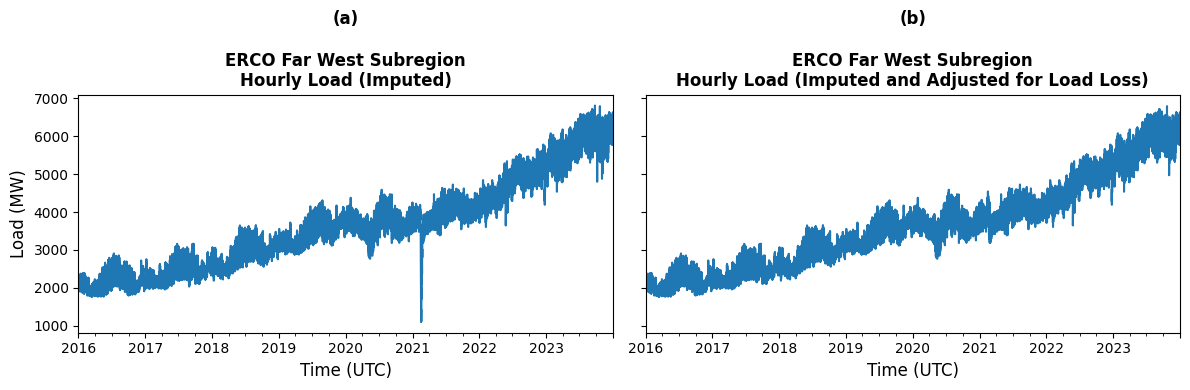

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

fwes_old.plot(ax=ax[0], legend=False)
ax[0].set_title('(a)\n\nERCO Far West Subregion\nHourly Load (Imputed)', fontweight='bold')
ax[0].set_xlabel('Time (UTC)', fontsize=12)
ax[0].set_ylabel('Load (MW)', fontsize=12)


fwes_new.loc[fwes_new.index.isin(fwes_old.index)].plot(ax=ax[1], legend=False)
ax[1].set_title('(b)\n\nERCO Far West Subregion\nHourly Load (Imputed and Adjusted for Load Loss)', fontweight='bold')
ax[1].set_xlabel('Time (UTC)', fontsize=12)

plt.tight_layout()
plt.savefig('load_loss_example.png', dpi=300, bbox_inches='tight')